## SIMULATION D'EQUATION DIFFERENTIELLE PATIELLE
### APPLICATION

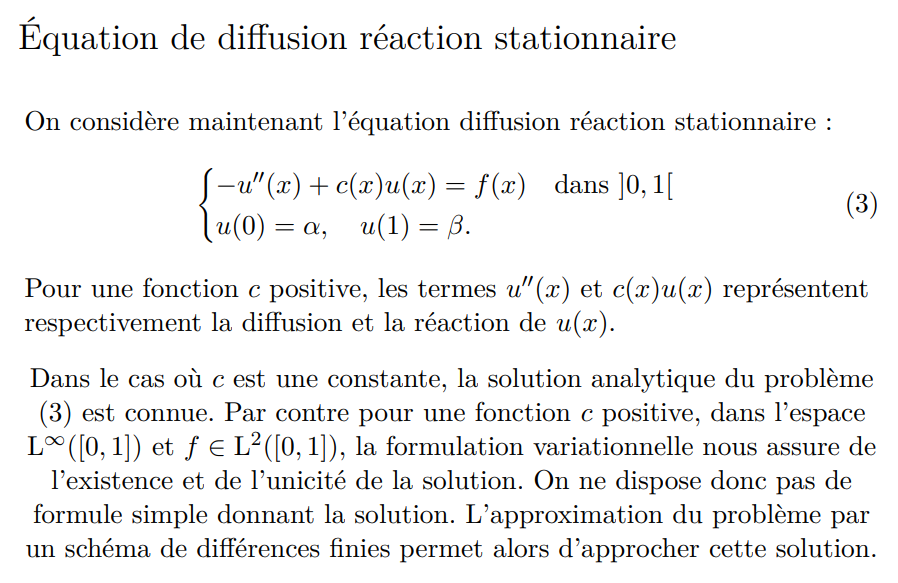

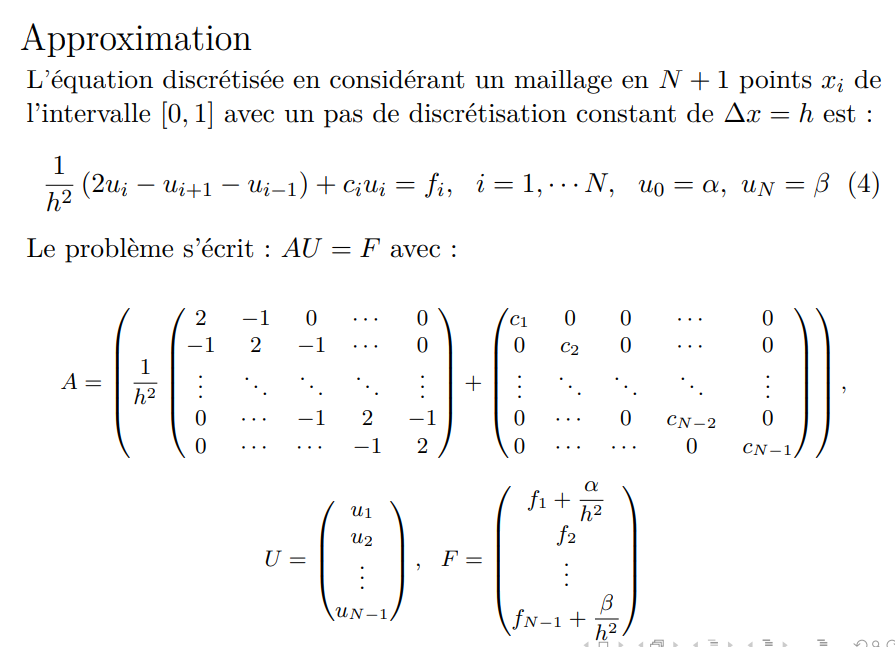

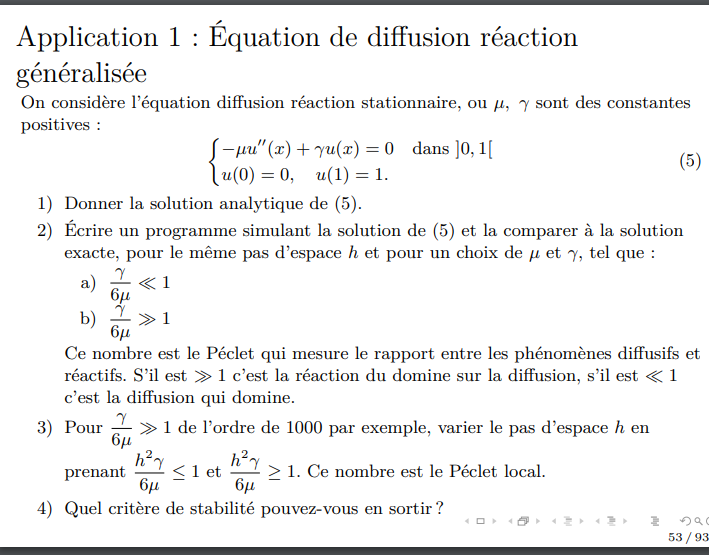

#### 1. La solution analytique de (5) 

In [1]:
from sympy import symbols, Function, Eq, dsolve, sin, cos, exp
from sympy.abc import x 
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
from scipy.sparse.linalg import spsolve
from scipy.linalg import norm

In [2]:
y = Function('y')
u, g = symbols('u g')

In [3]:
edp = Eq(-u*y(x).diff(x, 2) + g*y(x).diff(x) , 0)
solution_analytique = dsolve(edp, ics={y(0): 0, y(1): 1})
print("Solution particulière de l'EDO avec condition initiale:\n", solution_analytique)
print("\n")
solution_analytique

Solution particulière de l'EDO avec condition initiale:
 Eq(y(x), exp(g*x/u)/(exp(g/u) - 1) - 1/(exp(g/u) - 1))




Eq(y(x), exp(g*x/u)/(exp(g/u) - 1) - 1/(exp(g/u) - 1))

#### 2.Simulation de la solution de (5) 

a. La diffusion domine la réaction
$$ \frac{γ}{6µ} \ll 1$$  

In [87]:
#####################CONSTANTES##################

#####################DISCRETISATION DE L'ESPACE##################
NX = 10 # nbre de noeuds
x = np.linspace (0.0 ,1 , NX )
h = dx = 1/( NX -1) # Pas d'espace h
g = 0.01 # Coef de réaction
u = 1 # Coef de diffusion
# gamma / 6 * mu = 0.00166666666 << 1

#####################CONDITIONS LIMITES##################
alpha = 0
beta = 1


In [73]:
#####################FONCTIONS##################
# DEFINITION DE LA FONCTION SOURCE F 
def func1(x):  
    return 0
f = np.vectorize ( func1 )
# DEFINITION DE LA SOLUTION EXACTE (SOLUTION ANALYTIQUE)
def func2 ( x ):
    return (
        np.exp(g*x/u)/(np.exp(g/u) - 1) - 1/(np.exp(g/u) - 1)
         )
Uex = np.vectorize ( func2 )


C:\Users\User\AppData\Local\Temp\ipykernel_14824\637101092.py:25: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  Uint = spsolve(A , F )


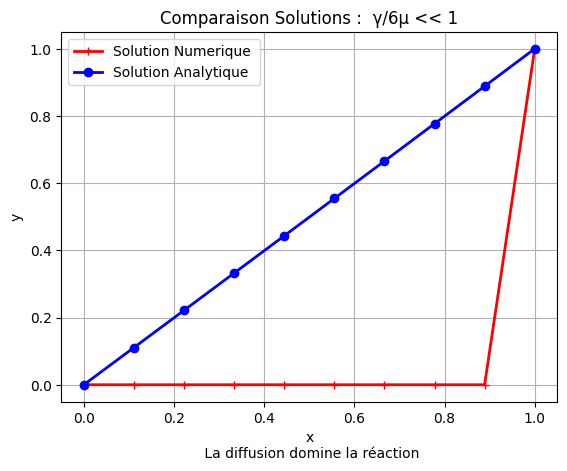

In [74]:
#--------------------------------------------------------
# %% Calcul de la Solution Discrete
#--------------------------------------------------------
def U_discret (x , NX , dx , f ):
    U = np.zeros ((NX))
    # Conditions limites
    U [0] = 0
    U [-1] = 1 
# Calcul de F = h² * f(x) : fonction source discrétisée
    F = (dx**2)* f(x)
    # F[f1 + alpha/h², ... , f(N-1) + beta/h²]
    #  or alpha = 0 , beta = 1 et N = 10
    #  donc F[f1, ... , f9 + 1/h²]
    F[0] = f(x[0]) + alpha / h**2
    F[-1] = f(x[-1]) + beta / h**2
    F = F [1: (NX-1)]
# Calcul de la matrice A
    val_diags = [ - np.ones ( NX-2) ,2* np.ones ( NX -2) , - np.ones ( NX -2)]
    positions = np.array ([ -1 ,0 ,1]) # Positions des diagonales
    A = sp.dia_matrix ( ( val_diags , positions ) , shape =( NX -2 , NX -2))
    A = A + (g * np.eye(NX -2)) 
# (g * np.eye(NX -2)) représente la fonction c(x) = g 
    
# Résolution de AU = F
    Uint = spsolve(A , F )
    U [1: NX-1] = Uint
    return ( U )
#%% # AFFICHAGE DES SOLUTIONS DISCRETES ET EXACTES COMPAREES
U = U_discret (x , NX , dx , f )
Uexact = Uex ( x )
fig , ax = plt.subplots (1)
ax.plot (x , U , 'r-+', lw =2 , label ='Solution Numerique ')
ax.plot (x , Uexact ,'b-o', lw =2 , label ='Solution Analytique ')
ax.set_xlabel ('x\n La diffusion domine la réaction') ; ax.set_ylabel ('y') 
# ax.set_xlim ([0 , 1])
# ax.set_ylim ([0 , 0.11])
ax.set_title ('Comparaison Solutions :  γ/6µ << 1')
ax.legend (); ax.grid ()

########################"Avertissement"############################
# C:\Users\User\AppData\Local\Temp\ipykernel_15460\850092065.py:17: 
# SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
# signifie que la fonction spsolve de scipy.sparse.linalg nécessite que la matrice A
# soit au format CSC (Compressed Sparse Column) ou CSR (Compressed Sparse Row) pour des 
# raisons d'efficacité. 


On constate une augmentaion réguliére et continue de 0 à 1 de la solution analytique (ligne bleue). (résultat attendu)

La solution numérique est presque plate de 0 et sur la majeure partie de l'intervalle, avec une brusque montée aprés 0.8 à 1.

La solution numérique ne capture pas correctement la variation progressive de la solution au milieu de l'intervalle.

Hormis les conditions limites, la méthode numérique a du mal à approximer la solution. Ceci peut être dû à la taille du maillage ou la fonction source ou le choix de gamma(γ) et mu(µ)

#### Changement du format de la matrice A

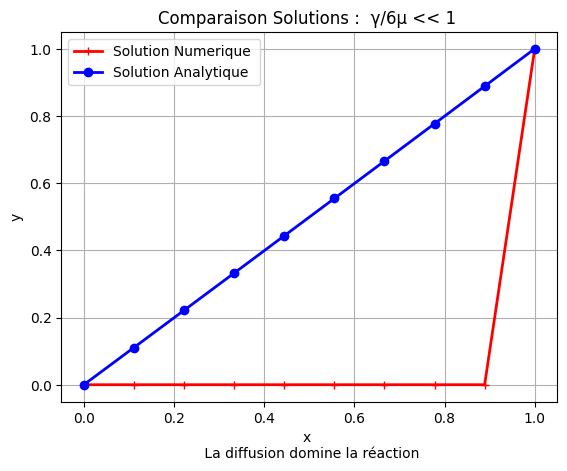

In [42]:
from scipy.sparse import csc_matrix, csr_matrix
#--------------------------------------------------------
# %% Calcul de la Solution Discrete
#--------------------------------------------------------
def U_discret (x , NX , dx , f ):
    U = np.zeros ((NX))
    # Conditions limites
    U [0] = 0
    U [-1] = 1 
# Calcul de F = h² * f(x) : fonction source discrétisée
    F = (dx**2)* f(x)
    # F[f1 + alpha/h², ... , f(N-1) + beta/h²]
    #  or alpha = 0 , beta = 1 et N = 10
    #  donc F[f1, ... , f9 + 1/h²]
    F[0] = f(x[0]) + alpha / h**2
    F[-1] = f(x[-1]) + beta / h**2
    F = F [1: (NX-1)]
# Calcul de la matrice A
    val_diags = [ - np.ones ( NX-2) ,2* np.ones ( NX -2) , - np.ones ( NX -2)]
    positions = np.array ([ -1 ,0 ,1]) # Positions des diagonales
    A = sp.dia_matrix ( ( val_diags , positions ) , shape =( NX -2 , NX -2))
    A = A + (g * np.eye(NX -2)) 
# (g * np.eye(NX -2)) représente la fonction c(x) = g 
     ########################## "format CSC" ##############################
    A = csc_matrix(A)
    # A = csr_matrix(A)
# Résolution de AU = F
    Uint = spsolve(A , F )
    U [1: NX-1] = Uint
    return ( U )
#%% # AFFICHAGE DES SOLUTIONS DISCRETES ET EXACTES COMPAREES
U = U_discret (x , NX , dx , f )
Uexact = Uex ( x )
fig , ax = plt.subplots (1)
ax.plot (x , U , 'r-+', lw =2 , label ='Solution Numerique ')
ax.plot (x , Uexact ,'b-o', lw =2 , label ='Solution Analytique ')
ax.set_xlabel ('x \n La diffusion domine la réaction') ; ax.set_ylabel ('y') 
ax.set_title ('Comparaison Solutions :  γ/6µ << 1 ')
ax.legend (); ax.grid ()



b. La réction domine la diffusion 
$$ \frac{γ}{6µ} \gg 1$$

In [96]:
#####################CONSTANTES##################
NX = 10 # nbre de noeuds
x = np.linspace (0.0 ,1 , NX )
h = dx = 1/( NX -1) # Pas d'espace
gamma = g = 1 # Coef de réaction
mu = u = 0.01 # Coef de diffusion
alpha = 0
beta = 1
# gamma / 6 * mu = 16.666666666666668  >> 1


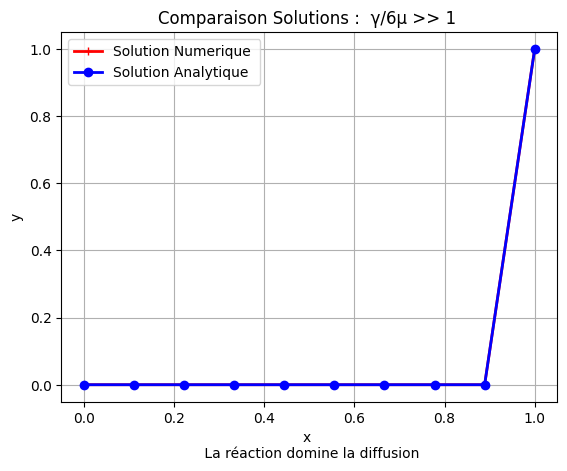

In [76]:
#--------------------------------------------------------
# %% Calcul de la Solution Discrete
#--------------------------------------------------------
def U_discret (x , NX , dx , f ):
    U = np.zeros ((NX))
    # Conditions limites
    U [0] = 0
    U [-1] = 1 
# Calcul de F = h² * f(x) : fonction source discrétisée
    F = (dx**2)* f(x)
    # F[f1 + alpha/h², ... , f(N-1) + beta/h²]
    #  or alpha = 0 , beta = 1 et N = 10
    #  donc F[f1, ... , f9 + 1/h²]
    F[0] = f(x[0]) + alpha / h**2
    F[-1] = f(x[-1]) + beta / h**2
    F = F [1: (NX-1)]
# Calcul de la matrice A
    val_diags = [ - np.ones ( NX-2) ,2* np.ones ( NX -2) , - np.ones ( NX -2)]
    positions = np.array ([ -1 ,0 ,1]) # Positions des diagonales
    A = sp.dia_matrix ( ( val_diags , positions ) , shape =( NX -2 , NX -2))
    A = A + (g * np.eye(NX -2)) 
# (g * np.eye(NX -2)) représente la fonction c(x) = g 
     ########################## "format CSC" ##############################
    A = csc_matrix(A)
    # A = csr_matrix(A)
# Résolution de AU = F
    Uint = spsolve(A , F )
    U [1: NX-1] = Uint
    return ( U )
#%% # AFFICHAGE DES SOLUTIONS DISCRETES ET EXACTES COMPAREES
U = U_discret (x , NX , dx , f )
Uexact = Uex ( x )
fig , ax = plt.subplots (1)
ax.plot (x , U , 'r-+', lw =2 , label ='Solution Numerique ')
ax.plot (x , Uexact ,'b-o', lw =2 , label ='Solution Analytique ')
ax.set_xlabel ('x \n La réaction domine la diffusion') ; ax.set_ylabel ('y') 
# ax.set_xlim ([0 , 1])
# ax.set_ylim ([0 , 0.11])
ax.set_title ('Comparaison Solutions :  γ/6µ >> 1 ')
ax.legend (); ax.grid ()



Les courbes de la solution analytique et de la solution numérique sont superposées, ce qui indique que la méthode numérique utilisée est très précise pour ce problème particulier. 

La correspondance étroite entre les deux solutions valide l'implémentation de la méthode numérique, y compris les conditions aux limites, la construction de la matrice et la résolution du système linéaire. 

De plus, cela démontre que la méthode est stable pour les paramètres choisis (valeurs de **NX, dx, g, u**). 

En conclusion, la méthode numérique reproduit fidèlement la solution analytique, confirmant ainsi son efficacité et sa précision pour résoudre cette équation différentielle.

#### 3. Pour $$ \frac{\gamma}{6\mu} \gg 1 $$ de l'ordre 1000, Variation du pas d'espace h en prenant
$$ \frac{h^2 \cdot \gamma}{6 \cdot \mu} \leq 1 $$ 
$$ \frac{h^2 \cdot \gamma}{6 \cdot \mu} \geq 1 $$


**1er cas :** Si h²γ/6µ <= 1 alors h ∈ [0; 1/sqrt(Peclet)]

In [92]:
import math
#####################Pour h²γ/6µ <= 1 sachant que γ/6µ >> 1 ##################
gamma = g = 6000
mu = u = 1
Peclet = g / (6*u) # Peclet = 1000
h_cas1= 1 / math.sqrt(Peclet)
NX_cas1 = int(1 /h_cas1) + 1 # d'aprés la relation  h = dx = 1/( NX -1) # Pas d'espace
x_cas1 = np.linspace (0.0 ,1 , NX_cas1 ) # NX_cas1 = 32.622776601683796 => 32

**Donc si h²γ/6µ <= 1 alors NX >= sqrt(Peclet) + 1** 

In [93]:
NX_cas1 = 40
x_cas1 = np.linspace (0.0 ,1 , NX_cas1 )
dx_cas1 = 1/( NX_cas1 -1)
gamma = g = 6000
mu = u = 1
alpha = 0
beta = 1


**2em cas :** Si h²γ/6µ >= 1 alors h >= 1/sqrt(Peclet)

**Donc si h²γ/6µ >= 1 alors NX <= sqrt(Peclet) + 1** 

In [94]:
NX_cas2 = 5
x_cas2 = np.linspace (0.0 ,1 , NX_cas2 )
dx_cas2 = 1/( NX_cas2 - 1)
gamma = g = 6000
mu = u = 1
alpha = 0
beta = 1

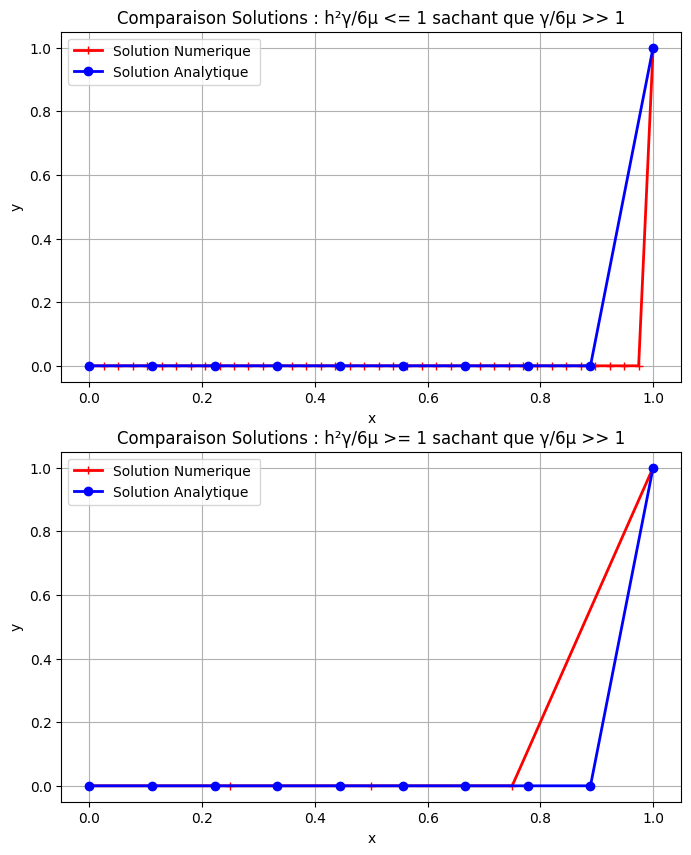

In [97]:
#%% # AFFICHAGE DES SOLUTIONS DISCRETES ET EXACTES COMPAREES
#########################CAS 1 : h²γ/6µ <= 1######################
fig, ax = plt.subplots(2, 1, figsize=(8, 10))
U_cas1 = U_discret (x_cas1 , NX_cas1 , dx_cas1 , f )
Uexact = Uex (x)
# fig , ax = plt.subplots (1)
ax[0].plot (x_cas1 , U_cas1 , 'r-+', lw =2 , label ='Solution Numerique ')
ax[0].plot (x , Uexact ,'b-o', lw =2 , label ='Solution Analytique ')
ax[0].set_xlabel ('x') 
ax[0].set_ylabel ('y') 
ax[0].set_title ('Comparaison Solutions : h²γ/6µ <= 1 sachant que γ/6µ >> 1')
ax[0].legend ()
ax[0].grid ()

#########################CAS 2 : h²γ/6µ >= 1######################
U_cas2 = U_discret (x_cas2 , NX_cas2 , dx_cas2 , f )
Uexact = Uex (x)
# fig , ax = plt.subplots (1)
ax[1].plot (x_cas2 , U_cas2 , 'r-+', lw =2 , label ='Solution Numerique ')
ax[1].plot (x , Uexact ,'b-o', lw =2 , label ='Solution Analytique ')
ax[1].set_xlabel ('x') 
ax[1].set_ylabel ('y') 
ax[1].set_title ('Comparaison Solutions : h²γ/6µ >= 1 sachant que γ/6µ >> 1')
ax[1].legend ()
ax[1].grid ()


Analyse : 
Courbe (h²γ/6μ <= 1) : On constate un excellent accord entre la solution numérique (rouge) et la solution analytique (bleue). Les deux courbes se superposent presque parfaitement. Cela indique une stabilité de la méthode numérique dans ce régime.

Courbe (h²γ/6μ >= 1) : Ici, un désaccord significatif apparaît entre les deux solutions. La solution numérique diverge de la solution analytique, présentant une instabilité. Cela suggère une instabilité de la méthode numérique lorsque cette condition est remplie.

Lorsque h²γ/6μ est petit (inférieur ou égal à 1), la discrétisation est suffisamment fine par rapport aux propriétés du problème pour que la méthode numérique converge vers la solution exacte.

En revanche, lorsque h²γ/6μ devient grand (supérieur ou égal à 1), la discrétisation devient trop grossière, et les erreurs numériques s'amplifient à chaque itération, menant à l'instabilité observée.

#### 4. Critére de stabilité
En analysant les deux courbes, on peut déduire que la courbe est :

    - Stable si h².g/6µ <= 1

    - Instable si h².g/6µ >= 1    